# Introduction

In [2]:
!pip install lightkurve

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 85.8 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=dcb2c5fdee81cb73c4f2622d4d70179dd55b82cb316a7a6dc442d5b4d0029713
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f622795b09e83471a3be5d2581cd9cf96a6ec7aa78e8deffe
  Created wheel for memoization: 

In [3]:
import lightkurve as lk
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Exoplanets
> Exoplanets are planets that orbit stars outside of our solar system. NASA is interested in searching for exoplanets because they want to answer the age old question.

`Is there life out there?`

>Studying and looking for exoplanets may help answer this question.

## Transit Method

> Planets orbit their host stars. Sometimes, these planets pass between the viewer and its star.
This is called a transit. Transits cause the light from the star to be a bit less than regular. Constant "dips" in the amount of light from a star hint towards there being an exoplanet in the star system. Transits can tell us many things:


```
The time in between transits tells us how long that planet's "year" is.
>-
Using how much the brightness drops, you can tell the size of the planet.
>-
```
> Kepler-10b is a rocky exoplanet with an orbital period of approximately 0.84 days.
## Light Curve
> A light curve plots the brightness (in magnitude or flux) relative to time.
> An example curve looks like this:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;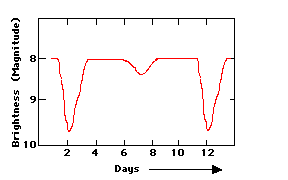
> Light curves help visualize the data gathered, and also helps with finding exoplanets for different stars.
## Dataset
> This project uses data from the Kepler space telescope, which measured the brightness variation of around 200,000 stars.

>The data in this project was retrieved from LightKurve's Python library. It provides lightcurves and tools for working with them. Each light curve contains measurements of stellar brightness (flux) taken at regular time intervals, allowing changes in brightness to be analyzed.

> The stars observed by kepler have a **KIC ID**. In this analysis, light curve data is downloaded for a Kepler star and then examined for possible exoplanet transits.
## Goal
>The objective of this project is to analyze time-series photometric data from the Kepler mission to detect potential transit events. By examining variations in stellar brightness over time, I aim to identify short-duration dips that may correspond to planets orbiting the target star.

#Data Retrieval

## Finding light curve through the LightKurve library
> For this analysis, the star Kepler- 10 (KIC 11904151) was chosen. Kepler - 10 hosts the confirmed exoplanet Kepler - 10b.
> Kepler - 10b has an orbital period of approximately 0.84 Earth-days. As a result, the planet transits its host star frequently, producing multiple detectable dips in the stellar light curve.
>

In [14]:
from lightkurve import search_targetpixelfile
pixelfile = search_targetpixelfile("KIC 11904151", quarter=1).download();

###Kepler has different quarters. Changing the quarter tells the program which quarter data you are looking at.The quarters are split up into 90 day segments, where they realign so the solar panels can face the sun.



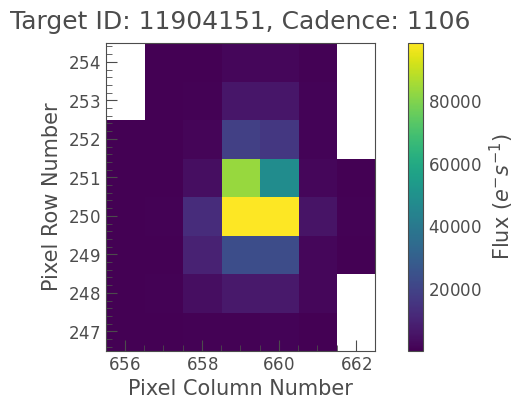

In [18]:
pixelfile.plot(frame=1);
# This shows the flux graph of Kepler - 10 during the first quarter.

### Now the pixel graph will be converted into a lightcurve for better visualization.

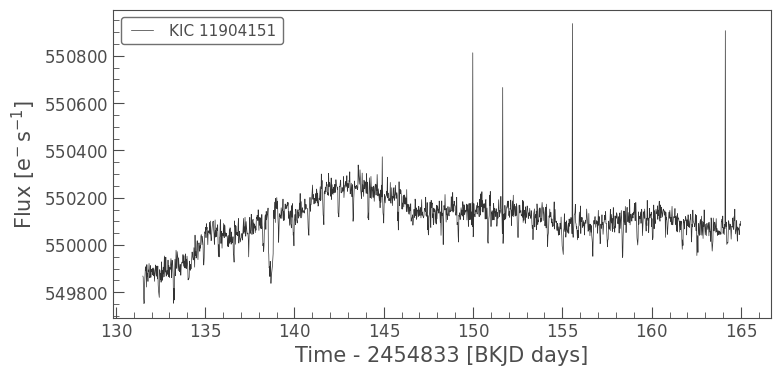

In [15]:
lc =  pixelfile.to_lightcurve(aperture_mask='all'); #light curve generation from the time and flux
lc.time #returns the time period
lc.flux # returns the flux for a time period
lc.plot(); # genuinely plots the points

This light curve is still messy. It's hard to grasp anything from this. Those sudden peaks are likely from other things - cosmic ray hits, telescope pointing adjustments, detector glitches, spacecraft momentum dumps

# Data Cleaning

We will begin by removing the following:

*   **NaNs** - not a number. Often times, data is recorded that has a missing or an invalid value.
*   **Outliers** - Values that are extremely different from the rest of data. These are oftentimes caused by glitches, and other things talked about in the above section.

**Normalize** changes the star's flux to deviate around 1 flux instead of a big number like 550600 in the previous graph.





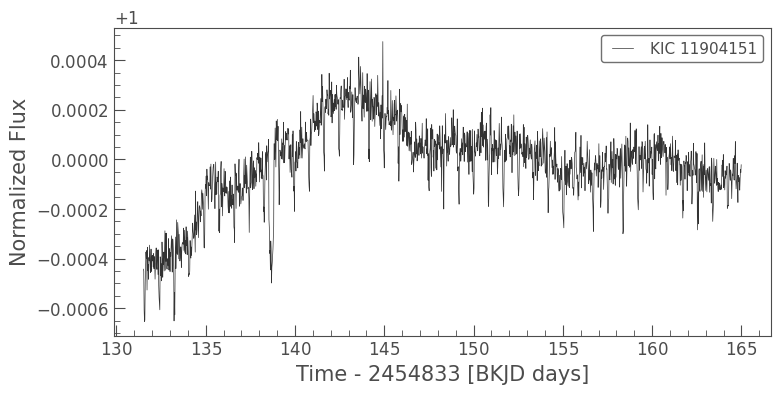

In [23]:
lc = lc.remove_nans().remove_outliers().normalize()
lc.plot();

The raw curve shows slow trends everywhere. This is inevitable because of how telescopes are, caused by sensor sensitivity changes or other things. The next step to clean the data is to flatten the graph so that it removes the slow trend and leaves only the small short-term variations.
Instead of plotting it, I chose to scatter it. This plots individual points and doesn't draw lines that connect each point.  

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

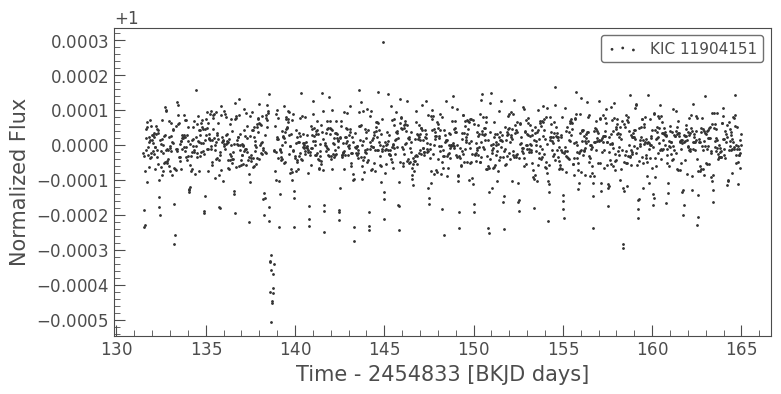

In [20]:
flat_lc = lc.flatten()
flat_lc.scatter()

# Light Curve Visualization

Let's visualize the Light Curve

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

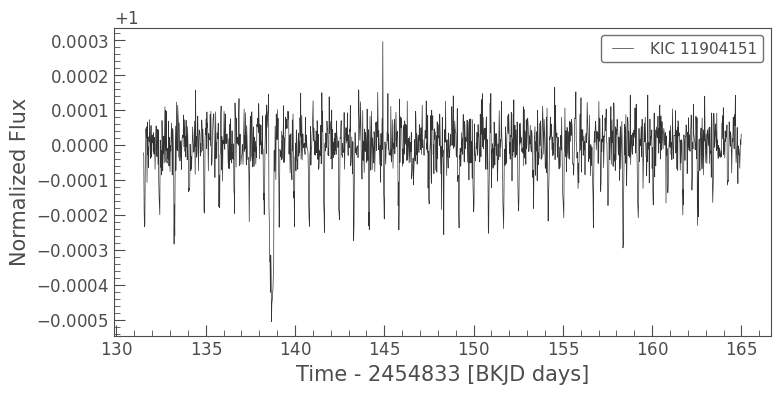

In [32]:
flat_lc.plot()

# Transit Detection

## Individual Traits are hard to see
> The data contains many fluctuations which come from seperate events and not exoplanet transits. Clean up was needed to get rid of those events and have a cleaner graph to visualize the transit.

## Phase Folding

>Phase folding aligns repeated transit events in the dataset, allowing the signal to be more visible. The period was set to the known orbital period of Kepler - 10b.


## Binning
> There is a lot of noise in the data-sets even after this. The folded data was then **binned** to remove noise with LightKurve's 0.01 phase interval.

## The detected dip
> The folded and binned light curve shows a clear dip in brightness near the transit phase. This dip corresponds to the moment when the planet passes in front of its host star, blocking a small fraction of the starlight. From the light curve, the dip in flux is about 0.00015.

Although the light curve is good, it's still hard to figure out where Kepler - 10b transits. Exoplanet transits have very small flux deviations. This last clean-up ensures a clear dip.

Phase folding aligns repeated transit events in the dataset, allowing the signal to be more visible. The period was set to the known orbital period of Kepler - 10b.

The folded data was then binned to remove noise with LightKurve's 0.01 phase interval.

In [ ]:
folded_lc = flat_lc.fold(period=0.8375)
binned_lc = folded_lc.bin(time_bin_size=0.01)

Now that the full clean-up is done, we can visualize the final light-curve.
I'll graph the folded one with scatter and the binned one with plot.

 The folded light curve is shown as a scatter plot to display the individual brightness measurements. A binned version of the data is plotted on top which reduced noise and highlights the shape of the transit.

Text(0.5, 1.0, 'Phase-Folded Transit of Kepler-10b')

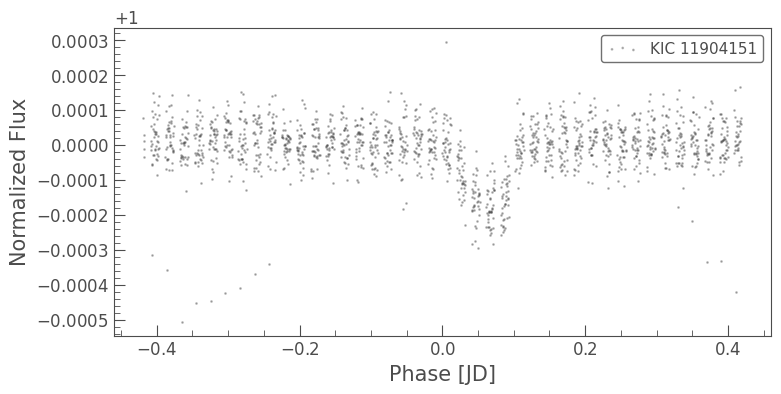

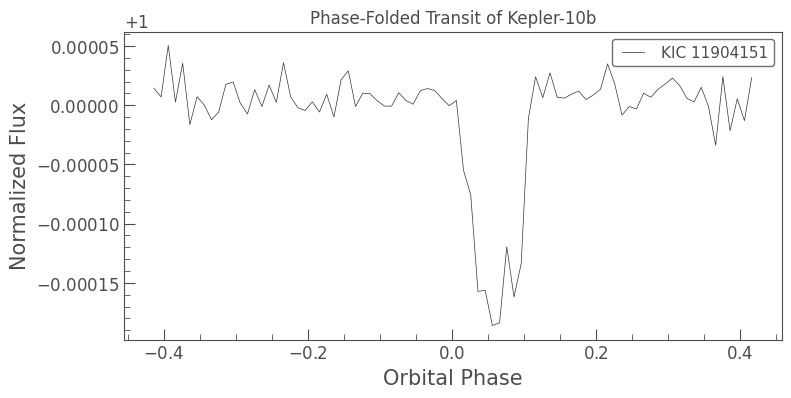

In [33]:
folded_lc.scatter(alpha=0.3)
binned_lc.plot()
plt.xlabel("Orbital Phase") # These are labels of the graphs.
plt.ylabel("Normalized Flux")
plt.title("Phase-Folded Transit of Kepler-10b")

## Before removing NaNs, normalizing and flattening, the light-curve looked like this. 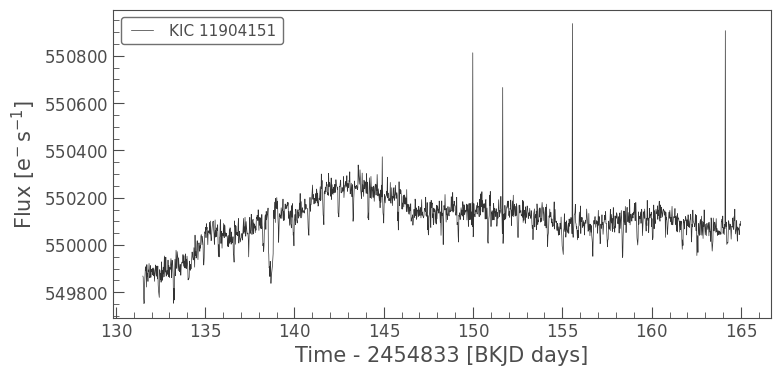

## After the first clean-up but before the folding and binning, the light curve looked like this.
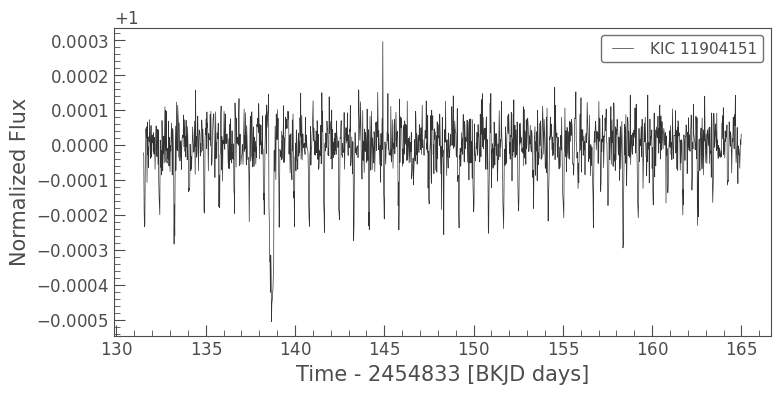


## After folding and binning, the light curve has a clear dip in brightness corresponding to the transit of Kepler-10b.
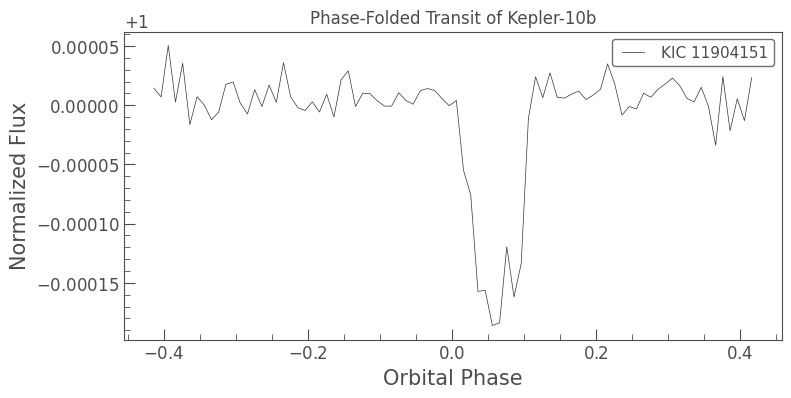

##

# Results

After preprocessing the light curve and applying phase folding and binning, a clear transit signal was detected. The phase-folded light curve shows a beautiful dip in brightness which corresponds to the transit of Kepler-10b across Kepler-10.

The transit depth is approximately ~0.00015 in normalized flux, meaning the star's brightness decreases by about 0.015% during the transit.
This is a small drop in brightness, and it would be hard to uncover this without cleaning the data.  

The repeated appearance of this dip across the folded light curve confirms the periodic transit signal associated with the exoplanet Kepler-10b.

# Discussion



## Why phase folding worked
> The phase folding worked because the orbital period of Kepler - 10b was known. Using its orbital period, the data points were folded to visualize a clear dip.

## Noise in the data
> This set contains many data points. Within these data points are common abnormalities. Additional noise sources include instrumental systematics, stellar variability, and photon noise from the Kepler detector. Exoplanet's transit flux are very tiny, and we just found that Kepler - 10b has a transit depth of only ~0.00015 in normalized flux. It is important to clean, normalize and fold the data to visualize the transit curve.

## Limits of the method
> Kepler - 10b's orbital period was already known. This was used to fold the data points and visualize the transit curve. Had it been a new exoplanet, folding based on orbital period would be impossible because it would be unknown.

## Possible improvements
> A possible improvement would be to determine the orbital period directly from the light curve instead of relying on the already known period of Kepler-10b. This would make the method more realistic for detecting unknown exoplanets. The analysis could also be improved by using additional observation quarters and applying more advanced noise-reduction or transit-search techniques.

> The "Box Least Squares" could be employed here. Instead of the period being a known value for folding, this algorithm checks different possible values of the period. It looks for dips in the light curves and tests the different values to see which matches the dips the best. After figuring out the period that is most accurate, it would fold using that period, allowing the curve to be visualized even when the orbital period is unknown.

> Using the transit depth, calculation of the Radius is possible through the formula $ (R_p / R_*)^2 $. Where $R_p $ is the radius of the planet and $R_*$ is the radius of the star.

> 0.00015 transit depth was measured. Plugging this into the equation
$$
\text{Transit depth} \approx \left(\frac{R_p}{R_*}\right)^2
$$

$$
0.00015 \approx \left(\frac{R_p}{R_*}\right)^2
$$

$$
\frac{R_p}{R_*} \approx \sqrt{0.00015}
$$

$$
\frac{R_p}{R_*} \approx 0.012
$$

> We come to the conclusion that the radius of Kepler - 10b is 1.2% that of Kepler - 10. For comparison, the Earth is 0.92% the radius of the Sun. These ratios are of the same order of magnitude, this result is consistent with Kepler-10b being a rocky, Earth-sized planet orbiting a Sun-like star. However, Kepler-10b orbits extremely close to its star and is likely far too hot to support life as we know it. This analysis demonstrates how transit observations can be used to infer the physical properties of exoplanets.

# Conclusion

>In this project, Kepler light curve data were analyzed to detect the transit signal of Kepler-10b. After cleaning the data, removing trends, and phase-folding the light curve, a clear transit dip was identified. The measured transit depth implies that the planet’s radius is approximately 1.2% of the radius of its host star, consistent with Kepler-10b being an Earth-sized rocky exoplanet. This analysis demonstrates how transit photometry can be used to infer physical properties of planets outside our solar system.

© 2026 Aarush Bagchi. All rights reserved.